<a href="https://colab.research.google.com/github/jiyuutheosum/Machine-Learning/blob/main/Dataset_1_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1: Importing Libraries**

In [ ]:
# Install required libraries
!pip install pandas numpy scikit-learn textblob nltk clean-text
!python -m textblob.download_corpora

import pandas as pd
import numpy as np
from textblob import TextBlob
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
nltk.download('stopwords')
nltk.download('wordnet')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.4/175.4 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.7.0-py3-none-any.whl size=171031 sha256=b6f20639212b1d659d5e1348b5bd829a419f68f84d18e1d7b53915c50ce68106
  Stored in directory: /root/.cache/pip/wheels/e0/8c/e0/294d2e4ea0e55792bfc99b6b263e4a0511443da7b69af67688
Successfully built emoji
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_d

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# **Step 2: Data Preparation**

In [14]:
# Example loading (change to your file name)
df = pd.read_csv('feedback_student.csv', encoding='latin1')

# Check the columns
df.head()

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def spellcheck(text):
    """
    Reusable spellchecker using TextBlob.
    """
    return str(TextBlob(text).correct())

def clean_text(text):
    """
    Full cleaning pipeline: lowercase, symbols removal, spacing,
    spellchecking, stopword removal, lemmatization, stemming.
    """
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Normalize repeated letters (e.g., goooood -> good)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Spellcheck
    text = spellcheck(text)

    # Remove stopwords
    text = " ".join([word for word in text.split() if word not in stop_words])

    # Lemmatization + Stemming
    text = " ".join([stemmer.stem(lemmatizer.lemmatize(word)) for word in text.split()])

    return text

df['cleaned_text'] = df['comment'].apply(clean_text)
df.head()

label_map = {
    'good': 1,
    'awful': 0,
    'poor': 0
}

df['label'] = df['quality'].map(label_map)

df.head()

,Id,comment,quality,cleaned_text,label
0,45881,"Rand was a good guy, really... he was. But I f...",awful,good guy realli felt alter left go home grade ...,0.0
1,45881,"He is brilliant in his field, but expects his ...",poor,brilliant field expect student perform high le...,0.0
2,45881,He has a major in philosophy which is why all ...,awful,major philosophi paper write base philosophi l...,0.0
3,45881,I thought his class was extremely hard but des...,good,thought class extrem hard despit becam confid ...,1.0
4,45881,I recently just finished taking Comp 110 with ...,poor,recent finish take come hardest class frenchma...,0.0


# **Step 3: Data Splitting**

In [16]:
from sklearn.model_selection import train_test_split

# Drop rows where 'label' is NaN
df_cleaned = df.dropna(subset=['label'])

X = df_cleaned['cleaned_text']
y = df_cleaned['label']

# Convert y to integer type, as labels are typically integers
y = y.astype(int)

# Train 70% | Validation 15% | Test 15%

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

len(X_train), len(X_val), len(X_test)

(934, 200, 201)

# **Step 4: Train Model**

In [17]:
# TF-IDF Feature Extraction with n-grams

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),  # unigrams + bigrams
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [18]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=2000)

In [19]:
# SVM
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

# **Step 5: Evaluation**

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate(model, X, y):
    preds = model.predict(X)

    # Metrics
    acc = accuracy_score(y, preds)
    prec = precision_score(y, preds)
    rec = recall_score(y, preds)
    f1 = f1_score(y, preds)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)

    # Confusion Matrix
    cm = confusion_matrix(y, preds)

    # Plot confusion matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Negative', 'Pred Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

Logistic Regression Performance:
Accuracy: 0.8308457711442786
Precision: 0.925
Recall: 0.5441176470588235
F1-score: 0.6851851851851852


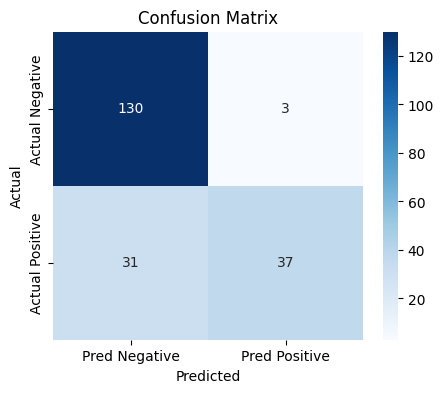

In [25]:
# Evaluate Logistic Regression

print("Logistic Regression Performance:")
evaluate(logreg, X_test_tfidf, y_test)

SVM Performance:
Accuracy: 0.8557213930348259
Precision: 0.8305084745762712
Recall: 0.7205882352941176
F1-score: 0.7716535433070866


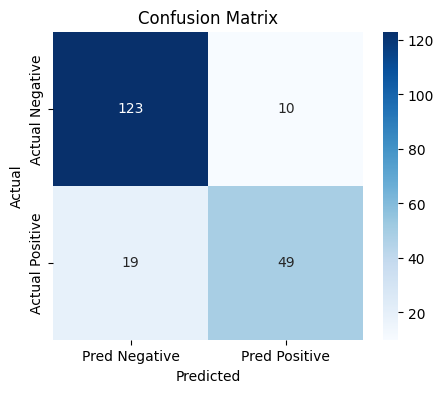

In [26]:
# Evaluate SVM

print("SVM Performance:")
evaluate(svm_model, X_test_tfidf, y_test)